<a href="https://colab.research.google.com/github/Aaryan8597/Big-Data/blob/main/Aaryan_Lamichhane_2408597.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Necessary Import

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Setting up Spark

In [ ]:
from pyspark.sql import SparkSession
spark = SparkSession.builder \
    .appName("SpotifyBigDataAnalysis") \
    .getOrCreate()

print("Spark Session Active")
from pyspark.sql.functions import col, sum
from pyspark.sql.functions import to_timestamp
from pyspark.sql.functions import year, hour, dayofweek, when
from pyspark.sql.functions import avg
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.classification import LogisticRegression, DecisionTreeClassifier, RandomForestClassifier
from pyspark.ml.evaluation import MulticlassClassificationEvaluator
from sklearn.metrics import confusion_matrix, classification_report

Spark Session Active


# Loading the Dataset

In [ ]:
df = spark.read.csv('/content/drive/MyDrive/Big Data/Aaryan_Lamichhane_2408597_BigData/spotify_history.csv', header = True)
# showing the first 5 rows of the dataset
df.show(5)

+--------------------+-------------------+----------+---------+--------------------+-----------------+--------------------+------------+----------+-------+-------+
|   spotify_track_uri|                 ts|  platform|ms_played|          track_name|      artist_name|          album_name|reason_start|reason_end|shuffle|skipped|
+--------------------+-------------------+----------+---------+--------------------+-----------------+--------------------+------------+----------+-------+-------+
|2J3n32GeLmMjwuAzy...|2013-07-08 02:44:34|web player|     3185| Say It, Just Say It|     The Mowgli's|Waiting For The Dawn|    autoplay|  clickrow|  FALSE|  FALSE|
|1oHxIPqJyvAYHy0PV...|2013-07-08 02:45:37|web player|    61865|Drinking from the...|    Calvin Harris|           18 Months|    clickrow|  clickrow|  FALSE|  FALSE|
|487OPlneJNni3NWC8...|2013-07-08 02:50:24|web player|   285386|         Born To Die|     Lana Del Rey|Born To Die - The...|    clickrow|   unknown|  FALSE|  FALSE|
|5IyblF777jLZj1v

# Data Cleaning

## Identifying Missing Values

In [ ]:
missing_values = df.select([sum(col(c).isNull().cast("int")).alias(c) for c in df.columns])

print("Missing Values per column:")
missing_values.show()

Missing Values per column:
+-----------------+---+--------+---------+----------+-----------+----------+------------+----------+-------+-------+
|spotify_track_uri| ts|platform|ms_played|track_name|artist_name|album_name|reason_start|reason_end|shuffle|skipped|
+-----------------+---+--------+---------+----------+-----------+----------+------------+----------+-------+-------+
|                0|  0|       0|        0|         0|          0|         0|         143|       117|      0|      0|
+-----------------+---+--------+---------+----------+-----------+----------+------------+----------+-------+-------+



## Filling Missing Values

In [ ]:
#filling the word 'unknown' in null places in 'reason_start' and 'reason_end'
df = df.fillna("unknown", subset=["reason_start", "reason_end"])
print("Filling missing values with 'unknown' completed.")
df.select(sum(col("reason_start").isNull().cast("int")).alias("nulls_in_reason_start"),
    sum(col("reason_end").isNull().cast("int")).alias("nulls_in_reason_end")).show()

Filling missing values with 'unknown' completed.
+---------------------+-------------------+
|nulls_in_reason_start|nulls_in_reason_end|
+---------------------+-------------------+
|                    0|                  0|
+---------------------+-------------------+



## Checking for Duplicate

In [ ]:
#counting every rows
total_rows = df.count()

#counting only the unique rows
unique_rows = df.distinct().count()
duplicate_count = total_rows - unique_rows
print(f"Number of duplicate rows found: {duplicate_count}")

Number of duplicate rows found: 1185


## Removing Duplicate Rows

In [ ]:
df = df.dropDuplicates()
print(f"Rows remaining after removing duplicates: {df.count()}")

Rows remaining after removing duplicates: 148675


## Filtering Zero-Plays Rows

In [ ]:
# Counting rows with 0 ms_played
zero_play_count = df.filter(col("ms_played").cast("int") == 0).count()
print(f"Number of rows with 0 ms played: {zero_play_count}")
# Removing zero-play rows
df = df.filter(col("ms_played").cast("int") > 0)
print(f"Final row after cleaning: {df.count()}")

Number of rows with 0 ms played: 3536
Final row after cleaning: 145139


# Feature Engineering

## Converting Timestamp to Datetime

In [ ]:
#converting the 'ts' column to timestamp format
df = df.withColumn("ts", to_timestamp(col("ts")))
#checking data type to confirm it is now a timestamp
df.select("ts").printSchema()

root
 |-- ts: timestamp (nullable = true)



## Extracting time-based features

In [ ]:
#extracting year
df = df.withColumn("year", year(col("ts")))
#extracting hour (0-23)
df = df.withColumn("hour", hour(col("ts")))
#extracting the day of the week
df = df.withColumn("day_of_week", dayofweek(col("ts")))
df = df.withColumn("day_name",
    when(col("day_of_week") == 2, "Monday")
    .when(col("day_of_week") == 3, "Tuesday")
    .when(col("day_of_week") == 4, "Wednesday")
    .when(col("day_of_week") == 5, "Thursday")
    .when(col("day_of_week") == 6, "Friday")
    .when(col("day_of_week") == 7, "Saturday")
    .when(col("day_of_week") == 1, "Sunday"))
df.select("ts", "year", "hour", "day_name").show(10)

+-------------------+----+----+---------+
|                 ts|year|hour| day_name|
+-------------------+----+----+---------+
|2015-01-12 22:34:41|2015|  22|   Monday|
|2015-06-14 19:14:11|2015|  19|   Sunday|
|2015-06-24 23:15:46|2015|  23|Wednesday|
|2015-06-24 23:55:46|2015|  23|Wednesday|
|2015-07-03 22:48:46|2015|  22|   Friday|
|2015-08-05 23:33:41|2015|  23|Wednesday|
|2015-08-05 23:36:38|2015|  23|Wednesday|
|2015-08-12 02:26:11|2015|   2|Wednesday|
|2015-08-20 07:17:34|2015|   7| Thursday|
|2015-08-25 00:02:43|2015|   0|  Tuesday|
+-------------------+----+----+---------+
only showing top 10 rows


## calculating listening hours

In [ ]:
#converting milliseconds to hours
df = df.withColumn("hours_played", col("ms_played").cast("float") / (1000 * 60 * 60))
#calculating the total hours played using sum
total_hours_row = df.select(sum("hours_played")).collect()
total_hours = total_hours_row[0][0]
print(f"Total Listening Time: {total_hours:.2f} hours")

Total Listening Time: 5288.73 hours


# EDA

## RQ1

### Listening Intensity change from 2013-2024

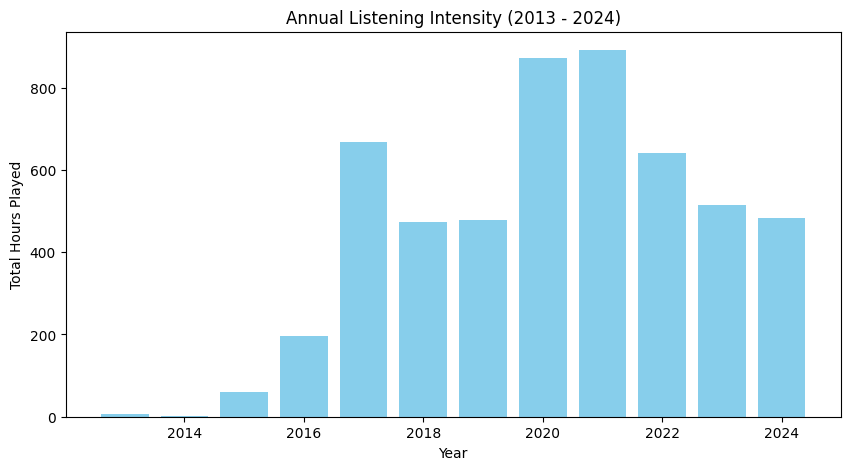

In [ ]:
annual_trends = df.groupBy("year").agg(sum("hours_played").alias("total_hours")).toPandas()
annual_trends = annual_trends.sort_values('year')
plt.figure(figsize=(10, 5))
plt.bar(annual_trends['year'], annual_trends['total_hours'], color='skyblue')
plt.title('Annual Listening Intensity (2013 - 2024)')
plt.xlabel('Year')
plt.ylabel('Total Hours Played')
plt.show()

### Analysis of Covid-19 impact

Pre-COVID Average: 269.59 hours
During COVID Average: 881.44 hours
Post-COVID Average: 546.24 hours


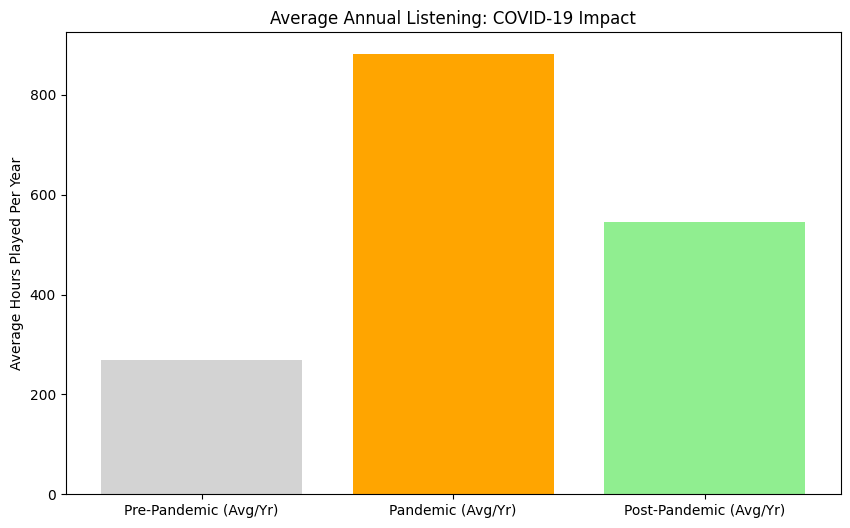

In [ ]:
#calculating averages for the three time periods
pre_covid_avg = annual_trends[annual_trends['year'] < 2020]['total_hours'].mean()
during_covid_avg = annual_trends[(annual_trends['year'] >= 2020) & (annual_trends['year'] <= 2021)]['total_hours'].mean()
post_covid_avg = annual_trends[annual_trends['year'] > 2021]['total_hours'].mean()

print(f"Pre-COVID Average: {pre_covid_avg:.2f} hours")
print(f"During COVID Average: {during_covid_avg:.2f} hours")
print(f"Post-COVID Average: {post_covid_avg:.2f} hours")

periods = ['Pre-Pandemic (Avg/Yr)', 'Pandemic (Avg/Yr)', 'Post-Pandemic (Avg/Yr)']
average_values = [pre_covid_avg, during_covid_avg, post_covid_avg]

plt.figure(figsize=(10, 6))
plt.bar(periods, average_values, color=['lightgray', 'orange', 'lightgreen'])
plt.title('Average Annual Listening: COVID-19 Impact')
plt.ylabel('Average Hours Played Per Year')
plt.show()

### Finding which year was the peak listening hours

In [ ]:
peak_row = df.groupBy("year") \
          .agg(sum("hours_played").alias("total_hours")) \
          .orderBy(col("total_hours").desc()) \
          .first()
#extracting specific year and hours from the top row
peak_year = peak_row['year']
peak_hours = peak_row['total_hours']
print(f"Peak listening year was {peak_year} with {peak_hours:.2f} total hours.")

Peak listening year was 2021 with 891.49 total hours.


## RQ2

### Daily listening time pattern

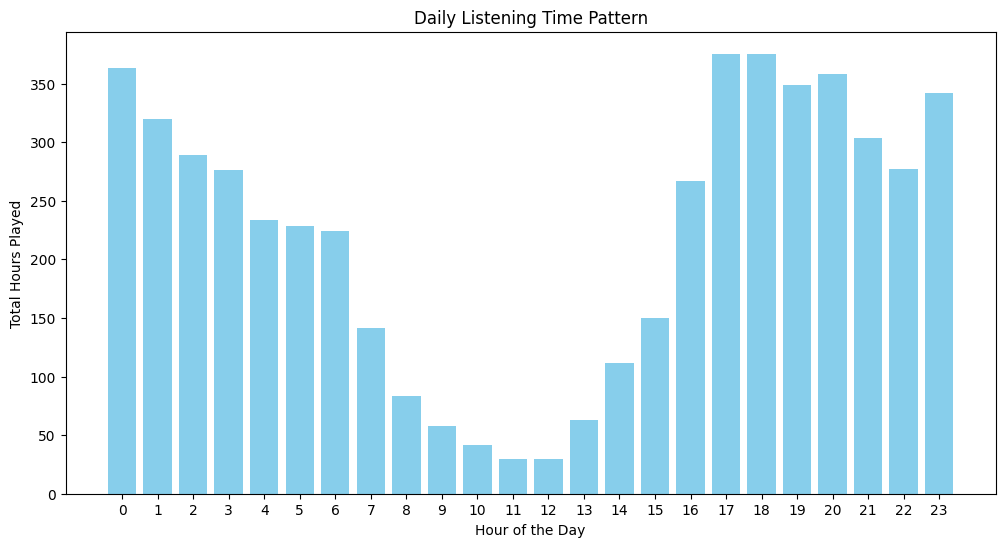

In [ ]:
hourly_trend = df.groupBy("hour").agg(sum("hours_played").alias("total_hours"))
hourly_trend = hourly_trend.orderBy("hour").toPandas()
#plotting the graph
plt.figure(figsize = (12,6))
plt.bar(hourly_trend["hour"], hourly_trend["total_hours"], color = "skyblue")
plt.title("Daily Listening Time Pattern")
plt.xlabel("Hour of the Day")
plt.ylabel("Total Hours Played")
plt.xticks(range(0,24))
plt.show()

### Weekly listening pattern

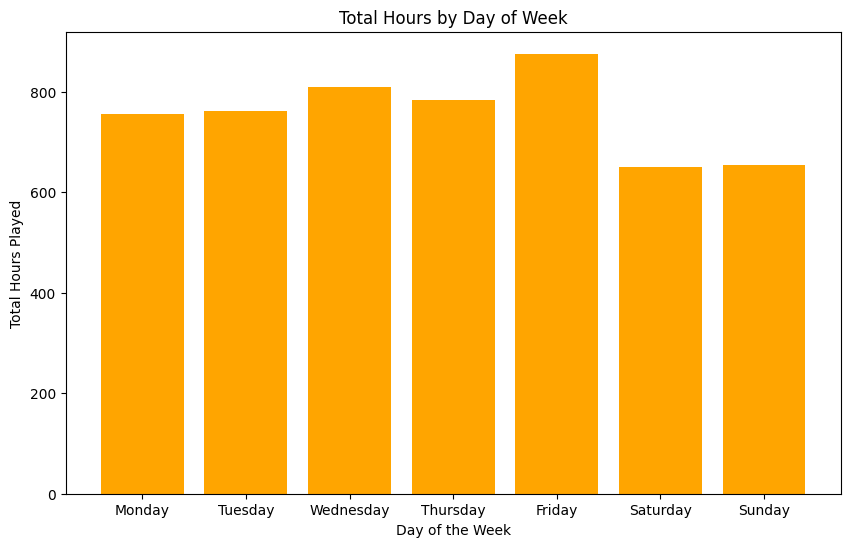

In [ ]:
weekly_trend = df.groupBy("day_name").agg(sum("hours_played").alias("total_hours")).toPandas()

day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
weekly_trend['day_name'] = pd.Categorical(weekly_trend['day_name'], categories=day_order, ordered=True)
weekly_trend = weekly_trend.sort_values('day_name')
# plotting graph
plt.figure(figsize=(10, 6))
plt.bar(weekly_trend['day_name'], weekly_trend['total_hours'], color='orange')

plt.title('Total Hours by Day of Week')
plt.xlabel('Day of the Week')
plt.ylabel('Total Hours Played')
plt.show()

## RQ3

### Top-10 artist by hours Played

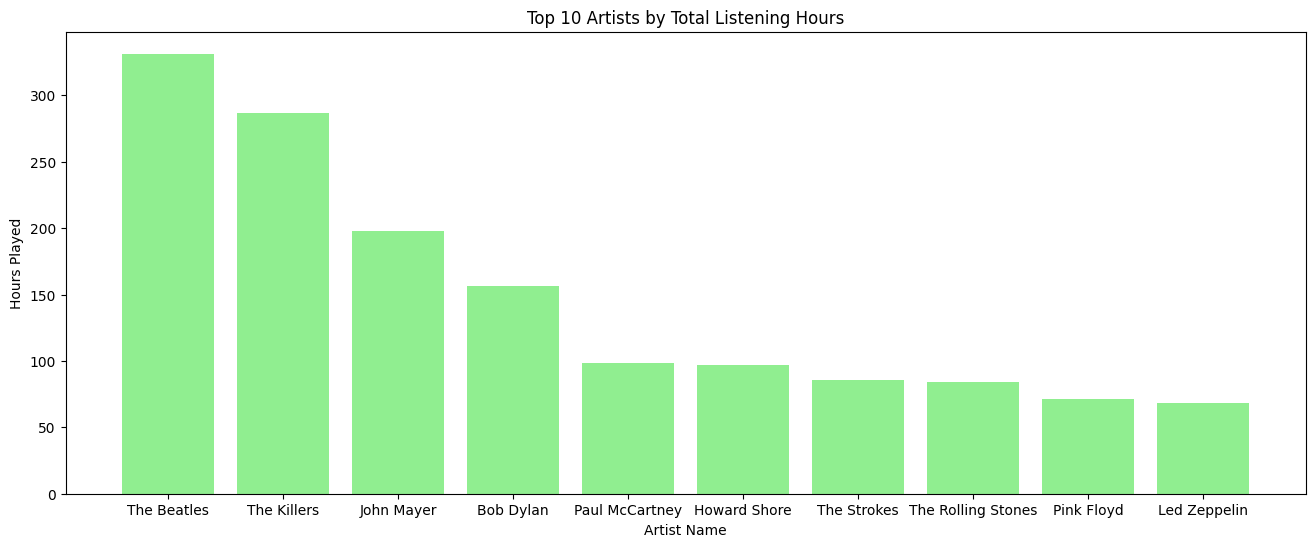

In [ ]:
top_artists_spark = df.groupBy("artist_name").agg(sum("hours_played").alias("total_hours"))
top_10_artists = top_artists_spark.orderBy(col("total_hours").desc()).limit(10).toPandas()

plt.figure(figsize=(16, 6))
plt.bar(top_10_artists['artist_name'], top_10_artists['total_hours'], color='lightgreen')

plt.title('Top 10 Artists by Total Listening Hours')
plt.xlabel('Artist Name')
plt.ylabel('Hours Played')
plt.show()

### Average minutes per Song for top artists

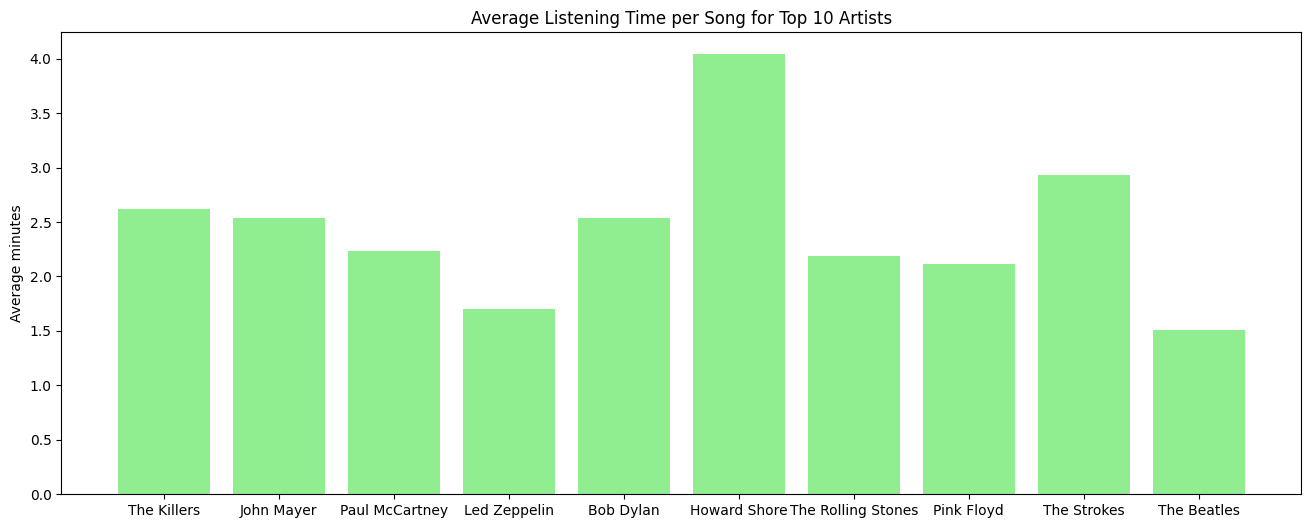

In [ ]:
#creating a column for minutes played
df = df.withColumn("minutes_played", (col("ms_played").cast("float") / 1000) / 60)
# calculating the average minutes for every artists
artist_averags = df.groupBy("artist_name").agg(avg("minutes_played").alias("avg_minutes"))

top_10_names = top_10_artists["artist_name"].tolist()
top_10_avg_minutes = artist_averags.filter(col("artist_name").isin(top_10_names)).toPandas()

plt.figure(figsize=(16, 6))
plt.bar(top_10_avg_minutes["artist_name"], top_10_avg_minutes["avg_minutes"], color="lightgreen")
plt.title("Average Listening Time per Song for Top 10 Artists")
plt.ylabel("Average minutes")
plt.show()

## RQ4

### Skip Rate analysis

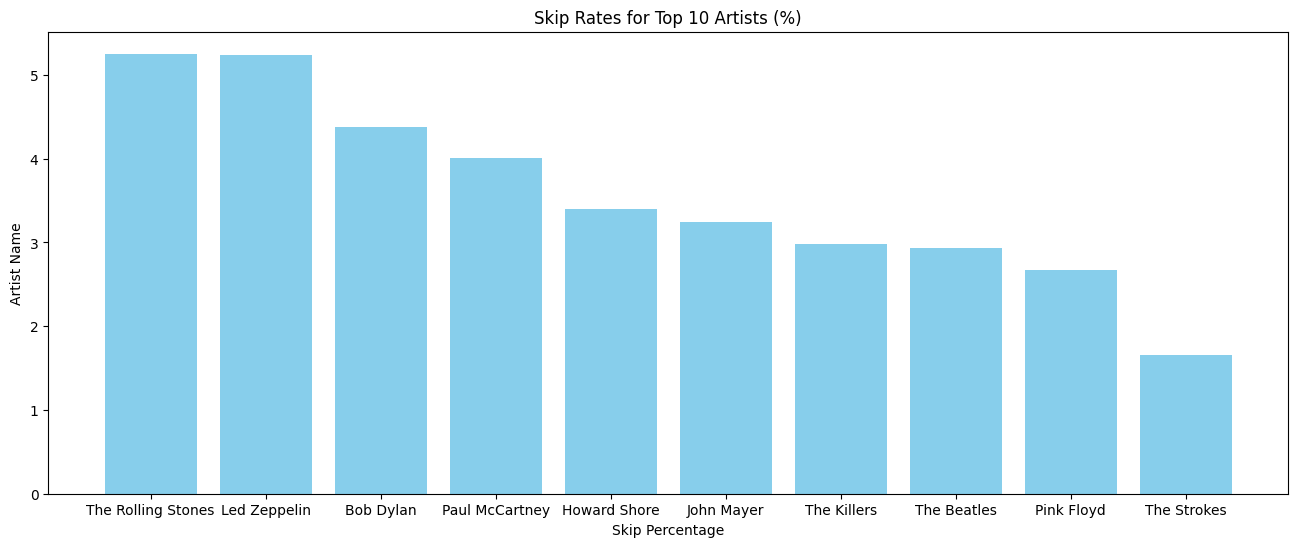

In [ ]:
# calculating the avergae skip rate per artist using mean
artist_skips = df.groupBy("artist_name").agg(avg(when(col("skipped") == "TRUE", 1).otherwise(0)).alias("avg_skip_rate"))
#filtering the top10 artists
top_10_names_list = top_10_artists["artist_name"].tolist()
top_10_skips = artist_skips.filter(col("artist_name").isin(top_10_names_list)).toPandas()
#sorting in order to match the order of top artists
top_10_skips = top_10_skips.sort_values(by = "avg_skip_rate", ascending = False)
#plotting the skip rates
plt.figure(figsize =(16,6))
plt.bar(top_10_skips["artist_name"], top_10_skips["avg_skip_rate"] * 100, color="skyblue")
plt.title("Skip Rates for Top 10 Artists (%)")
plt.xlabel("Skip Percentage")
plt.ylabel("Artist Name")
plt.show()

### When do Skip Happens

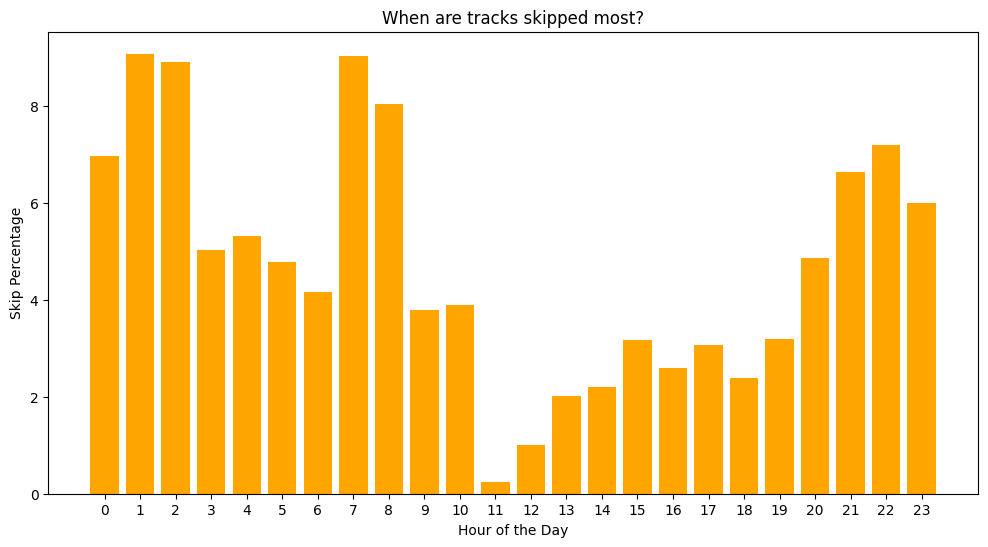

In [ ]:
# calculating the average skip rate for each hours
hourly_skips = df.groupBy("hour").agg(avg(when(col("skipped") == "TRUE", 1).otherwise(0)).alias("avg_skip_rate"))
hourly_skips = hourly_skips.orderBy("hour").toPandas()
#plotting the figure for hourly skips rate
plt.figure(figsize = (12,6))
#multiplying by 100 to show it in percentage
plt.bar(hourly_skips["hour"], hourly_skips["avg_skip_rate"] * 100, color = "orange")
plt.title("When are tracks skipped most?")
plt.xlabel("Hour of the Day")
plt.ylabel("Skip Percentage")
plt.xticks(range(0,24))
plt.show()

### Why do tracks gets skipped?

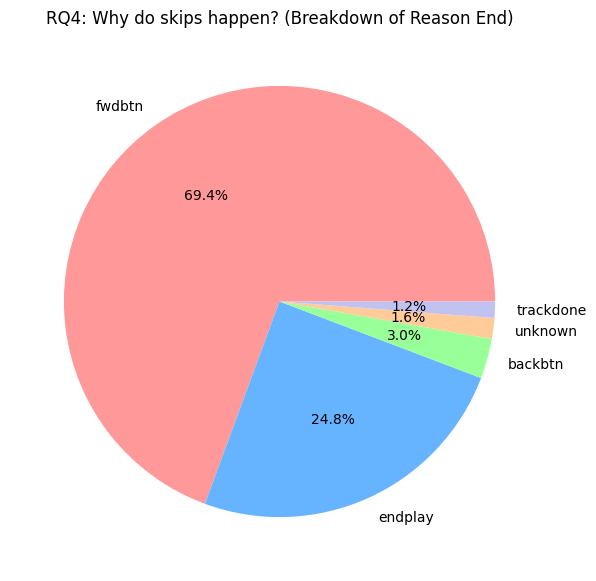

In [ ]:
#filtering the data where the skipped is true
reason_counts = df.filter(col("skipped") == "TRUE") \
                        .groupBy("reason_end") \
                        .count() \
                        .orderBy(col("count").desc()) \
                        .limit(5)
#counting the occurance of each reason in reason end
reason_counts = reason_counts.toPandas()
#plotting graph for showing why using a pie chart
plt.figure(figsize=(10, 7))
plt.pie(reason_counts['count'], labels=reason_counts['reason_end'], autopct='%1.1f%%', colors=['#ff9999','#66b3ff','#99ff99','#ffcc99', '#c2c2f0'])
plt.title("RQ4: Why do skips happen? (Breakdown of Reason End)")
plt.show()

## Music Taste shift (2013 vs 2024)

In [ ]:
top_3_2013 = df.filter(col("year") == 2013) \
                     .groupBy("artist_name") \
                     .agg(sum("hours_played").alias("total_hours")) \
                     .orderBy(col("total_hours").desc()) \
                     .limit(3)
top_3_2024 = df.filter(col("year") == 2024) \
                     .groupBy("artist_name") \
                     .agg(sum("hours_played").alias("total_hours")) \
                     .orderBy(col("total_hours").desc()) \
                     .limit(3)

print("--- Taste in 2013 ---")
top_3_2013.show()
print("\n--- Taste in 2024 ---")
top_3_2024.show()

--- Taste in 2013 ---
+------------+-------------------+
| artist_name|        total_hours|
+------------+-------------------+
|  John Mayer| 1.6526705555555556|
|Lana Del Rey| 0.6791575000000001|
|   The Kooks|0.43281888888888886|
+------------+-------------------+


--- Taste in 2024 ---
+-----------+------------------+
|artist_name|       total_hours|
+-----------+------------------+
| John Mayer|25.323128611111077|
|The Killers|22.613838888888875|
|The Beatles|        16.7223825|
+-----------+------------------+



# Logistic Regression

## Preparation of Data

In [ ]:
#converting 'skipped' from true/ false strings to 1/0 integers for the model
df_model = df.withColumn("label", when(col("skipped") == "TRUE", 1).otherwise(0))

#adding 'hour' and 'day_of_week' into a single features column
assembler = VectorAssembler(inputCols=["hour", "day_of_week"], outputCol="features")
output = assembler.transform(df_model)

#selecting only the column that is needed
final_data = output.select("features", "label")

#spliting the data in 80% train and 20% test
train_data, test_data = final_data.randomSplit([0.8, 0.2], seed=42)

## Training the model

In [ ]:
logistic_regression = LogisticRegression(featuresCol="features", labelCol="label")
#training the model
logistic_model = logistic_regression.fit(train_data)
# making prediction on 20% data
predictions = logistic_model.transform(test_data)

## Visualization

In [ ]:
evaluator = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction")

accuracy = evaluator.evaluate(predictions, {evaluator.metricName: "accuracy"})
precision = evaluator.evaluate(predictions, {evaluator.metricName: "weightedPrecision"})
recall = evaluator.evaluate(predictions, {evaluator.metricName: "weightedRecall"})

print(f"--- Logistic Model Performance ---")
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")

--- Logistic Model Performance ---
Accuracy:  0.9465
Precision: 0.8958
Recall:    0.9465


# Decision Tree (prediction on Weekday vs Weekend)

## Preparation of Data

In [ ]:
#defining the Weekend where saturday is 6 and sunday is 7
df_weekend = df.withColumn("label", when(col("day_of_week").isin(6, 7), 1).otherwise(0))
df_weekend = df_weekend.withColumn("skip_num", when(col("skipped") == "TRUE", 1).otherwise(0))
assembler_dt = VectorAssembler(inputCols=["hour", "skip_num"], outputCol="features")
final_data_dt = assembler_dt.transform(df_weekend).select("features", "label")
train_dt, test_dt = final_data_dt.randomSplit([0.8, 0.2], seed=42)

## Training the decision tree

In [ ]:
dt_weekend_model = DecisionTreeClassifier(labelCol="label", featuresCol="features")
#training model
dt_trained = dt_weekend_model.fit(train_dt)
#making predicitons
dt_predictions = dt_trained.transform(test_dt)

## Visualization

--- Decision Tree: Weekend Prediction ---
Accuracy:  0.7010
Precision: 0.6741
Recall:    0.7010


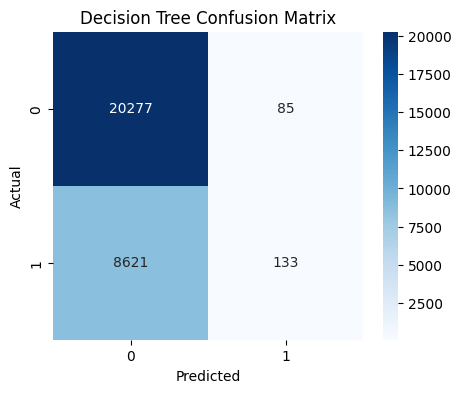

In [ ]:
evaluator = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction")

accuracy = evaluator.evaluate(dt_predictions, {evaluator.metricName: "accuracy"})
precision = evaluator.evaluate(dt_predictions, {evaluator.metricName: "weightedPrecision"})
recall = evaluator.evaluate(dt_predictions, {evaluator.metricName: "weightedRecall"})

print(f"--- Decision Tree: Weekend Prediction ---")
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")

y_true = dt_predictions.select("label").toPandas()
y_pred = dt_predictions.select("prediction").toPandas()
plt.figure(figsize=(5, 4))
sns.heatmap(confusion_matrix(y_true, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title('Decision Tree Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Random Forest (Predicting Time categories)

## Preparation of Data

In [ ]:
#creating the Multi-Class Label 0, 1, or 2
df_time = df.withColumn("label",  when((col("hour") >= 5) & (col("hour") < 12), 0)  # Morning
    .when((col("hour") >= 12) & (col("hour") < 17), 1) # Afternoon
    .otherwise(2)# Evening/Night
)

#Converting 'skipped' to numeric
df_time = df_time.withColumn("skip_num", when(col("skipped") == "TRUE", 1).otherwise(0))

assembler_rf = VectorAssembler(inputCols=["day_of_week", "skip_num"], outputCol="features")
final_data_rf = assembler_rf.transform(df_time).select("features", "label")

#spliting the data
train_rf, test_rf = final_data_rf.randomSplit([0.8, 0.2], seed=42)

## Training the Random Forest model

In [ ]:
random_forest = RandomForestClassifier(labelCol="label", featuresCol="features", numTrees=20)
#training the model
rf_model = random_forest.fit(train_rf)
#makingpredictions
rf_predictions = rf_model.transform(test_rf)

## Visualization

In [ ]:
accuracy_rf = evaluator.evaluate(rf_predictions, {evaluator.metricName: "accuracy"})
precision_rf = evaluator.evaluate(rf_predictions, {evaluator.metricName: "weightedPrecision"})
recall_rf = evaluator.evaluate(rf_predictions, {evaluator.metricName: "weightedRecall"})
f1_rf = evaluator.evaluate(rf_predictions, {evaluator.metricName: "f1"})

print(f"--- Random Forest: Time Category Prediction ---")
print(f"Accuracy:  {accuracy_rf:.4f}")
print(f"Precision: {precision_rf:.4f}")
print(f"Recall:    {recall_rf:.4f}")
print(f"F1-Score:  {f1_rf:.4f}")

--- Random Forest: Time Category Prediction ---
Accuracy:  0.7286
Precision: 0.5308
Recall:    0.7286
F1-Score:  0.6142


# Model Comparison

In [ ]:
evaluator = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction", metricName="accuracy")

print("--- Model Performance Comparison ---")
print(f"Logistic Regression Accuracy: {evaluator.evaluate(predictions):.4f}")
print(f"Decision Tree Accuracy:       {evaluator.evaluate(dt_predictions):.4f}")
print(f"Random Forest Accuracy:       {evaluator.evaluate(rf_predictions):.4f}")

--- Model Performance Comparison ---
Logistic Regression Accuracy: 0.9465
Decision Tree Accuracy:       0.7010
Random Forest Accuracy:       0.7286
